In [157]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import legendre
# from numba import njit
from tqdm.notebook import tqdm

# Assignment 1: Gaussian Quadrature

Daniel Sun

16 January 2026

## 1 Find the Sample Points $x_k$

We'll state some facts about Legendre polynomials from [Wikipedia](https://en.wikipedia.org/wiki/Legendre_polynomials#Zeros) without proof. The Legendre polynomial $P_n(x)$ has $n$ real, simple poles in the interval $(-1,1)$. Furthermore, the zeros of $P_n(\cos{\theta})$ are approximately distributed uniformly over the range $\theta\in(0,\pi)$. This motivates the starting guesses $x_k=\cos\left(\pi\frac{n-k-\frac14}{n+\frac12}\right)$, for $k\in\left\{0,1,\dotsc,n-1\right\}$. We will use the Newton-Raphson method for root-finding because of its efficient quadratic convergence.

In [158]:
eps = np.finfo(np.float64).eps
print(eps)

2.220446049250313e-16


In [159]:
def newton_raphson_step(f, df, x):
    return x - f(x) / df(x)

In [162]:
def leg_roots(n):
    assert n >= 0
    if n == 0:
        return np.array([])
    x = np.cos(np.pi * (n - np.arange(n) - 0.25) / (n + 0.5)) # Initial guesses
    x_new = newton_raphson_step(legendre(n), legendre(n).deriv(), x)
    while np.max(np.abs(x_new - x) > eps): # Convergence criterion appropriate for interval (-1, 1)
        x = x_new
        x_new = newton_raphson_step(legendre(n), legendre(n).deriv(), x)
    return x_new

In [163]:
for n in range(1, 11):
    print(f"Roots of P_{n}(x): ", leg_roots(n))
    print(f"Max magnitude of P_{n}(x) at roots: ", np.max(np.abs(legendre(n)(leg_roots(n)))))

Roots of P_1(x):  [0.]
Max magnitude of P_1(x) at roots:  0.0
Roots of P_2(x):  [-0.57735027  0.57735027]
Max magnitude of P_2(x) at roots:  3.3306690738754696e-16
Roots of P_3(x):  [-0.77459667  0.          0.77459667]
Max magnitude of P_3(x) at roots:  1.1102230246251565e-16
Roots of P_4(x):  [-0.86113631 -0.33998104  0.33998104  0.86113631]
Max magnitude of P_4(x) at roots:  3.3306690738754696e-16
Roots of P_5(x):  [-9.06179846e-01 -5.38469310e-01 -1.19850915e-94  5.38469310e-01
  9.06179846e-01]
Max magnitude of P_5(x) at roots:  1.1102230246251565e-15
Roots of P_6(x):  [-0.93246951 -0.66120939 -0.23861919  0.23861919  0.66120939  0.93246951]
Max magnitude of P_6(x) at roots:  3.3306690738754696e-16
Roots of P_7(x):  [-9.49107912e-01 -7.41531186e-01 -4.05845151e-01 -2.30113756e-92
  4.05845151e-01  7.41531186e-01  9.49107912e-01]
Max magnitude of P_7(x) at roots:  6.661338147750939e-16
Roots of P_8(x):  [-0.96028986 -0.79666648 -0.52553241 -0.18343464  0.18343464  0.52553241
  0.79

## 2 Find the Weights $w_k$

In [164]:
def indicator(k, x_list):
    # NB! k is 0-indexed
    x_list_trimmed = np.delete(x_list, k) # Creates a copy
    f = np.poly1d(x_list_trimmed, True)
    return f / np.prod(x_list[k] - x_list_trimmed)

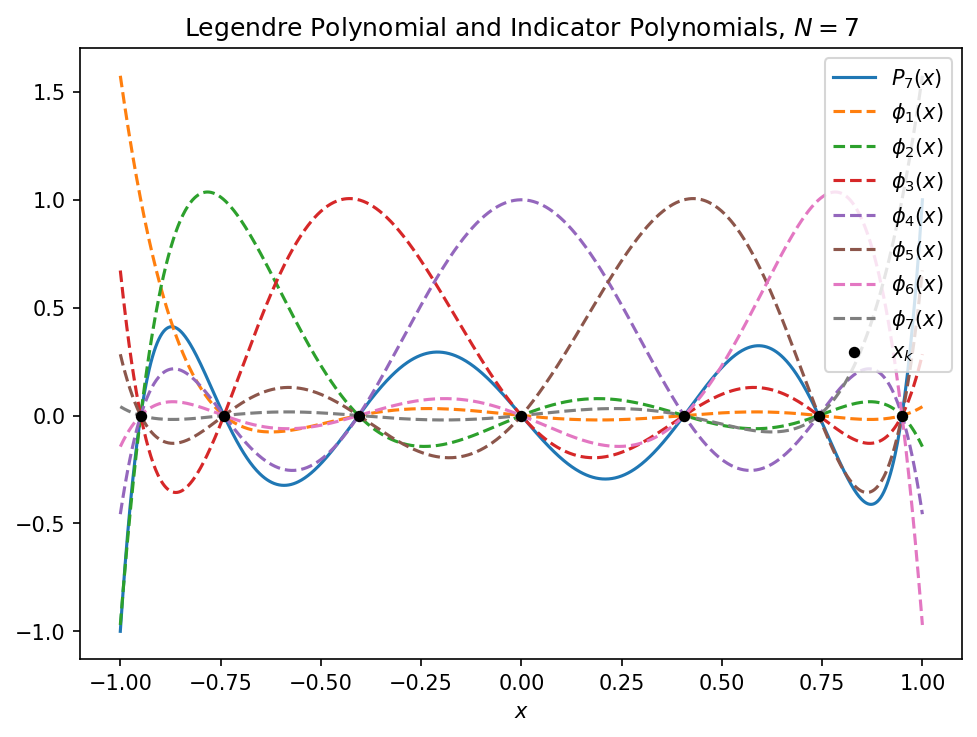

In [165]:
plt.subplots(dpi = 150, layout = "constrained")
x = np.linspace(-1, 1, 1001)
N = 7
plt.plot(x, legendre(N)(x), label = f"$P_{N}(x)$")
x_roots = leg_roots(N)
for k in range(N):
    phi_k = indicator(k, x_roots)
    plt.plot(x, phi_k(x), label = f"$\\phi_{k+1}(x)$", linestyle = "dashed") # 1-indexed for label
plt.scatter(x_roots, np.zeros_like(x_roots), s = 20, color = "black", label = "$x_k$", zorder = 5)

plt.xlabel("$x$")
plt.title(f"Legendre Polynomial and Indicator Polynomials, $N={N}$")
plt.legend()
plt.savefig(f"N_{N}_plot.png")

In [166]:
def interpolator(f, n): # Not vectorized to preserve np.poly1d type
    x_roots = leg_roots(n)
    indicators = [float(f(x_roots[k])) * indicator(k, x_roots) for k in range(n)]
    return sum(indicators)

In [167]:
def simpsons(f, n = 10**6, a = -1, b = 1):
    # Composite Simpsons' 1/3 rule
    x = np.linspace(a, b, 2 * n + 1, endpoint = True) # 2n subintervals
    h = (b - a) / (2 * n)
    y = f(x)
    return h / 3 * (4 * np.sum(y[1::2]) + 2 * np.sum(y[::2]) - y[0] - y[-1])

In [168]:
def quad_weights(n):
    x_roots = leg_roots(n)
    weights = np.zeros_like(x_roots)
    for k in range(n):
        phi_k = indicator(k, x_roots)
        weights[k] = simpsons(phi_k)
    return weights

## 3 Integrate!

In [169]:
# Pre-compute roots and weights
N = np.arange(11)
roots_list = [leg_roots(n) for n in N] # N x n ragged array
weights_list = [quad_weights(n) for n in N] # N x n ragged array

In [170]:
def integrate(f, a = -1, b = 1, N = 7):
    roots = np.array(roots_list[N])
    weights = np.array(weights_list[N])
    roots *= (b - a) / 2
    roots += (a + b) / 2
    weights *= (b - a) / 2
    y = f(roots)
    return np.sum(weights * y)

In [171]:
def integrate_intervals(f, a = -1, b = 1, N = 7, N_sub = 10):
    integral = 0.
    x = np.linspace(a, b, N_sub + 1, endpoint = True)
    for i in range(N_sub):
        integral += integrate(f, x[i], x[i + 1], N)
    return integral

### Test function 1
$$\int_0^1e^x\mathrm{d}x=e-1$$

0it [00:00, ?it/s]

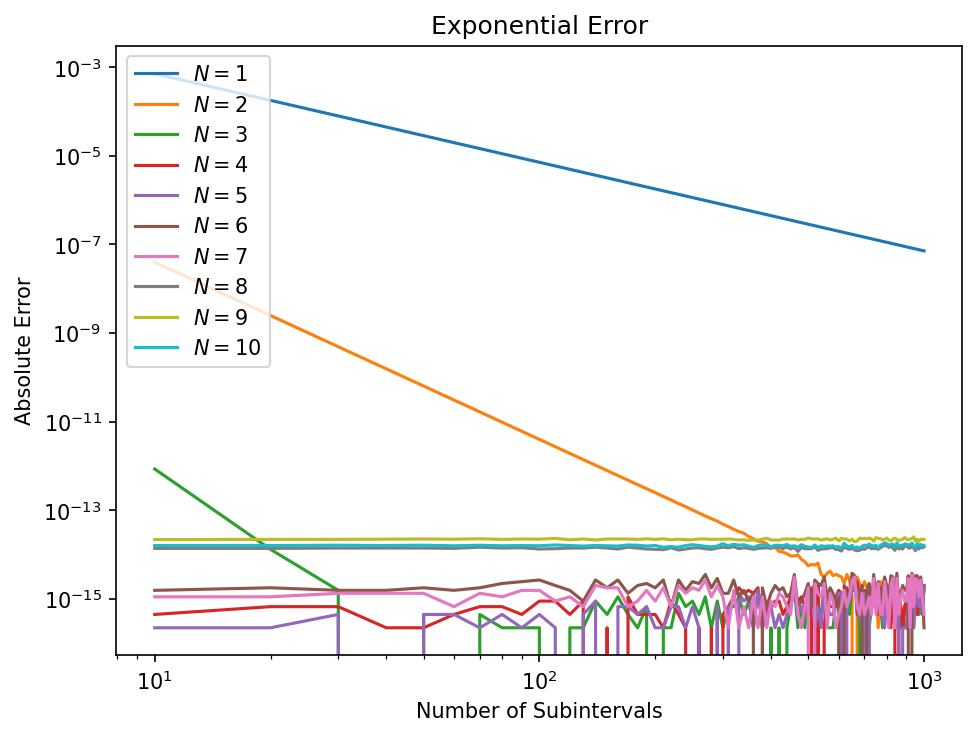

In [187]:
f = lambda x: np.exp(x)
a = 0
b = 1
true_value = np.e - 1

Ns = np.arange(1, 11)
N_subs = np.arange(10, 1001, 10)

errors = np.zeros((Ns.shape[0], N_subs.shape[0]))
for i, n in tqdm(enumerate(Ns)):
    for j, n_sub in enumerate(N_subs):
        integral = integrate_intervals(f, a, b, n, n_sub)
        errors[i, j] = np.abs(integral - true_value)

plt.subplots(dpi = 150, layout = "constrained")
for i, n in enumerate(Ns):
    plt.plot(N_subs, errors[i, :], label = f"$N={n}$")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Subintervals")
plt.ylabel("Absolute Error")
plt.title("Exponential Error")
plt.legend()
plt.savefig("exp_error.png")

### Test function 2
$$\int_1^{10}\left(\sqrt[3]{x}+\frac1{1+100(x-5)^2}\right)\mathrm{d}x=\frac1{20}\left(-15+150\sqrt[3]{10}+2\arctan(40)+2\arctan(50)\right)$$
This function is tricky because it has an awkward pointy bit at $x=5$ (proportional to a Cauchy distribution with HWHM of $\frac1{10}$). The integrator must have resolution better than this (that is, $N\cdot N_{\text{sub}}\gg\frac{b-a}{\gamma}=90$) to achieve accurate results. Also, integrators with low $N_{\text{sub}}$ cannot work, since the indicator polynomials are too smooth to capture the feature at $x=5$.

0it [00:00, ?it/s]

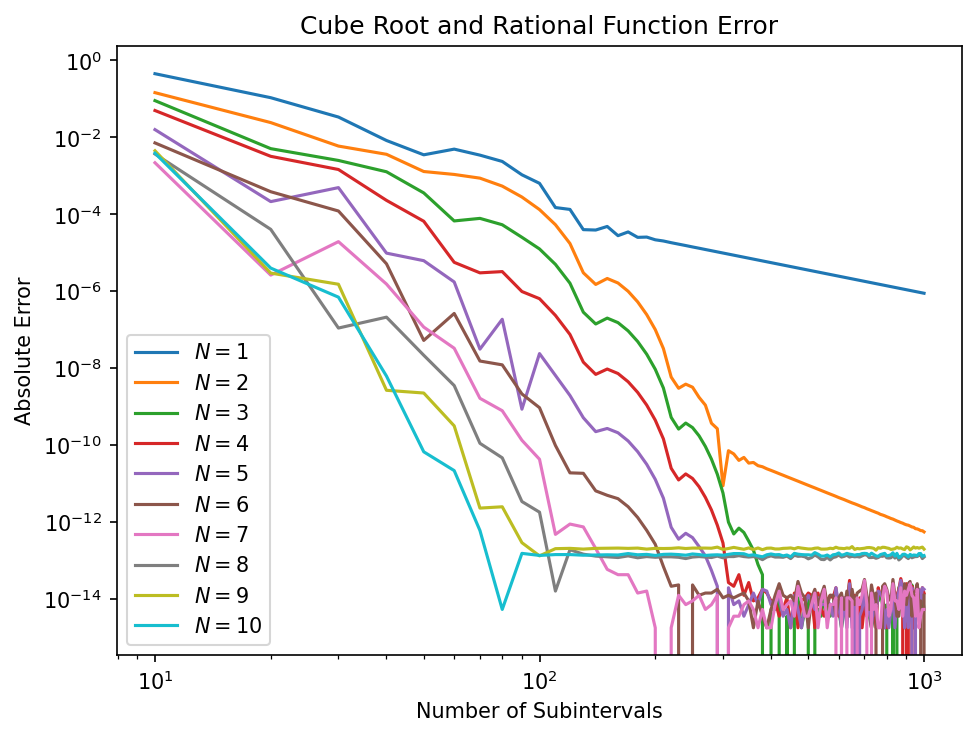

In [194]:
f = lambda x: np.cbrt(x) + 1 / (1 + 100 * (x - 5)**2)
a = 1
b = 10
true_value = (-15 + 150 * np.cbrt(10) + 2 * np.atan(40) + 2 * np.atan(50)) / 20

Ns = np.arange(1, 11)
N_subs = np.arange(10, 1001, 10)

errors = np.zeros((Ns.shape[0], N_subs.shape[0]))
for i, n in tqdm(enumerate(Ns)):
    for j, n_sub in enumerate(N_subs):
        integral = integrate_intervals(f, a, b, n, n_sub)
        errors[i, j] = np.abs(integral - true_value)

plt.subplots(dpi = 150, layout = "constrained")
for i, n in enumerate(Ns):
    plt.plot(N_subs, errors[i, :], label = f"$N={n}$")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Subintervals")
plt.ylabel("Absolute Error")
plt.title("Cube Root and Rational Function Error")
plt.legend()
plt.savefig("cbrt_error.png")

### Test function 3
$$\int_{-\pi}^{4-\pi}x^5\left|x\right|\mathrm{d}x=\frac{16384}7-4096\pi+3072\pi^2-1280\pi^3+320\pi^4-48\pi^5+4\pi^6-\frac27\pi^7$$
The integrand under consideration here can be written as $f(x)=x^6\mathop{\mathrm{sgn}}(x)$. With sufficiently high $N_{\text{sub}}$, it looks like $\pm x^6$, depending on the location of the interval. Therefore, it's well-interpolated by even-degree polynomials, but it's less well-interpolated by odd-degree polynomials. So, we have the best convergence for $N=8$ and $N=10$, but comparably worse performance for $N=7$ and $N=9$.

0it [00:00, ?it/s]

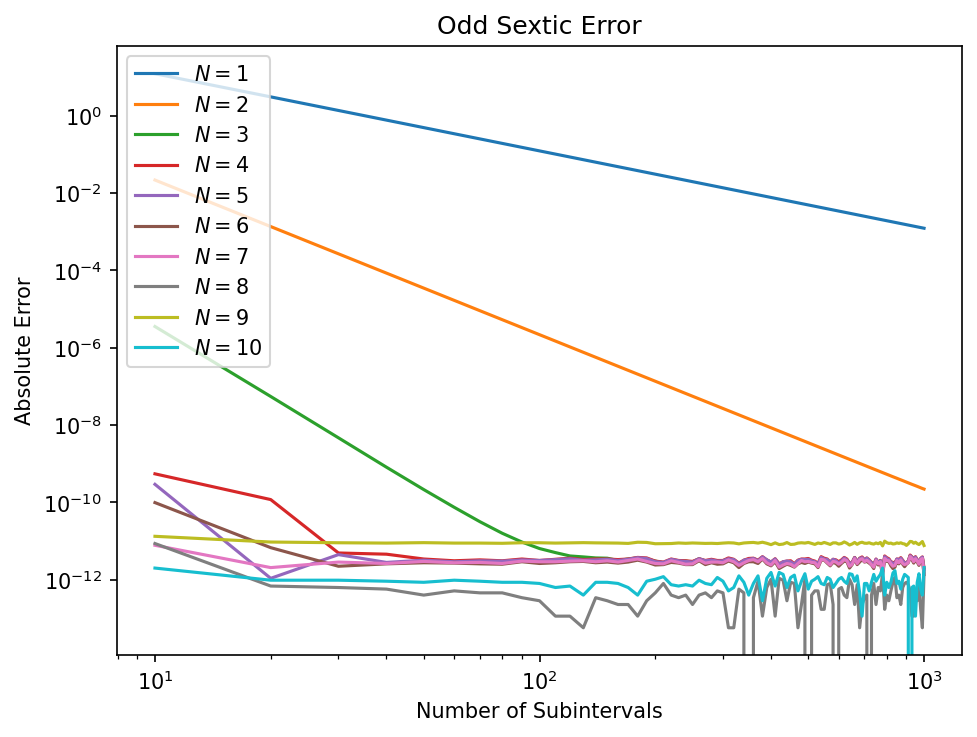

In [196]:
f = lambda x: x**5 * np.abs(x)
a = -np.pi
b = 4 - np.pi
true_value = 16384 / 7 - 4096 * np.pi + 3072 * np.pi**2 - 1280 * np.pi**3 + 320 * np.pi**4 - 48 * np.pi**5 + 4 * np.pi**6 - 2/7 * np.pi**7

Ns = np.arange(1, 11)
N_subs = np.arange(10, 1001, 10)

errors = np.zeros((Ns.shape[0], N_subs.shape[0]))
for i, n in tqdm(enumerate(Ns)):
    for j, n_sub in enumerate(N_subs):
        integral = integrate_intervals(f, a, b, n, n_sub)
        errors[i, j] = np.abs(integral - true_value)

plt.subplots(dpi = 150, layout = "constrained")
for i, n in enumerate(Ns):
    plt.plot(N_subs, errors[i, :], label = f"$N={n}$")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Subintervals")
plt.ylabel("Absolute Error")
plt.title("Odd Sextic Error")
plt.legend()
plt.savefig("sextic_error.png")